<a href="https://colab.research.google.com/github/junaid-pathan/trialforge/blob/main/Hack_Princeton_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q sdv scikit-learn shap matplotlib seaborn scipy kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
import kagglehub, os

# Download CDC Diabetes Health Indicators (BRFSS 2015)
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print(f"Available files: {csv_files}")

# Use the binary classification version
target_file = [f for f in csv_files if "binary" in f.lower() and "5050" not in f.lower()]
if target_file:
    csv_path = os.path.join(path, target_file[0])
else:
    csv_path = os.path.join(path, csv_files[0])
full_data = pd.read_csv(csv_path)
print(f"Full dataset: {full_data.shape}")

# Rename target column
if "Diabetes_binary" in full_data.columns:
    full_data = full_data.rename(columns={"Diabetes_binary": "target"})
elif "Diabetes_012" in full_data.columns:
    full_data = full_data.rename(columns={"Diabetes_012": "target"})
    full_data["target"] = (full_data["target"] > 0).astype(int)

# Clean column names (remove spaces)
full_data.columns = [c.strip().replace(" ", "_") for c in full_data.columns]
full_data["target"] = full_data["target"].astype(int)

# Stratified sample to 10,000 patients
data, _ = train_test_split(
    full_data, train_size=10000,
    random_state=42, stratify=full_data["target"]
)
data.reset_index(drop=True, inplace=True)

# 80/20 stratified split
train_real, test_real = train_test_split(
    data, test_size=0.2, stratify=data["target"], random_state=42
)

print(f"Sampled dataset: {data.shape[0]} patients, {data.shape[1]} columns")
print(f"Train set:       {len(train_real)} patients")
print(f"Test set:        {len(test_real)} patients (held out)")
print(f"Disease prevalence: {data['target'].mean():.1%}")
print()
data.head()


Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Available files: ['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']
Full dataset: (253680, 22)
Sampled dataset: 10000 patients, 22 columns
Train set:       8000 patients
Test set:        2000 patients (held out)
Disease prevalence: 13.9%



,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,12.0,4.0,7.0
1,0,0.0,1.0,1.0,29.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,5.0,0.0,0.0,1.0,6.0,6.0,8.0
2,0,0.0,0.0,1.0,30.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,5.0,0.0,0.0,1.0,8.0,6.0,8.0
3,0,0.0,0.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,30.0,0.0,0.0,0.0,6.0,6.0,8.0
4,0,0.0,0.0,1.0,51.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,25.0,0.0,0.0,0.0,2.0,6.0,6.0


In [3]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_real)

synthesizer = TVAESynthesizer(
    metadata,
    epochs=300,
    batch_size=32,
    compress_dims=(128, 64),
    decompress_dims=(64, 128),
    l2scale=1e-5,
    loss_factor=2
)
synthesizer.fit(train_real)

synthetic_data = synthesizer.sample(num_rows=len(train_real))

print("Synthetic patients generated!")
print(f"Shape: {synthetic_data.shape}")
print(f"Real disease prevalence:      {train_real['target'].mean():.1%}")
print(f"Synthetic disease prevalence:  {synthetic_data['target'].mean():.1%}")
print()
synthetic_data.head()

Synthetic patients generated!
Shape: (8000, 22)
Real disease prevalence:      13.9%
Synthetic disease prevalence:  13.3%



,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1.0,1.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,5.0,8.0
1,0,0.0,0.0,1.0,23.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
2,0,1.0,1.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,6.0,4.0,6.0
3,0,0.0,0.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0,5.0,7.0
4,0,1.0,1.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0


Continuous features (4): ['BMI', 'MentHlth', 'PhysHlth', 'Age']
Categorical features (17): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Education', 'Income']

Feature                 KS Stat   KS p-value  Wasserstein  Verdict
HighBP                   0.0519       0.0000       0.0519  DIVERGENT ✗
HighChol                 0.0435       0.0000       0.0435  DIVERGENT ✗
CholCheck                0.0281       0.0036       0.0281  DIVERGENT ✗
BMI                      0.0413       0.0000       0.7308  DIVERGENT ✗
Smoker                   0.0166       0.2189       0.0166  GOOD
Stroke                   0.0391       0.0000       0.0391  DIVERGENT ✗
HeartDiseaseorAttack     0.0838       0.0000       0.0837  DIVERGENT ✗
PhysActivity             0.1998       0.0000       0.1998  DIVERGENT ✗
Fruits                   0.2746       0.0000       0.2746

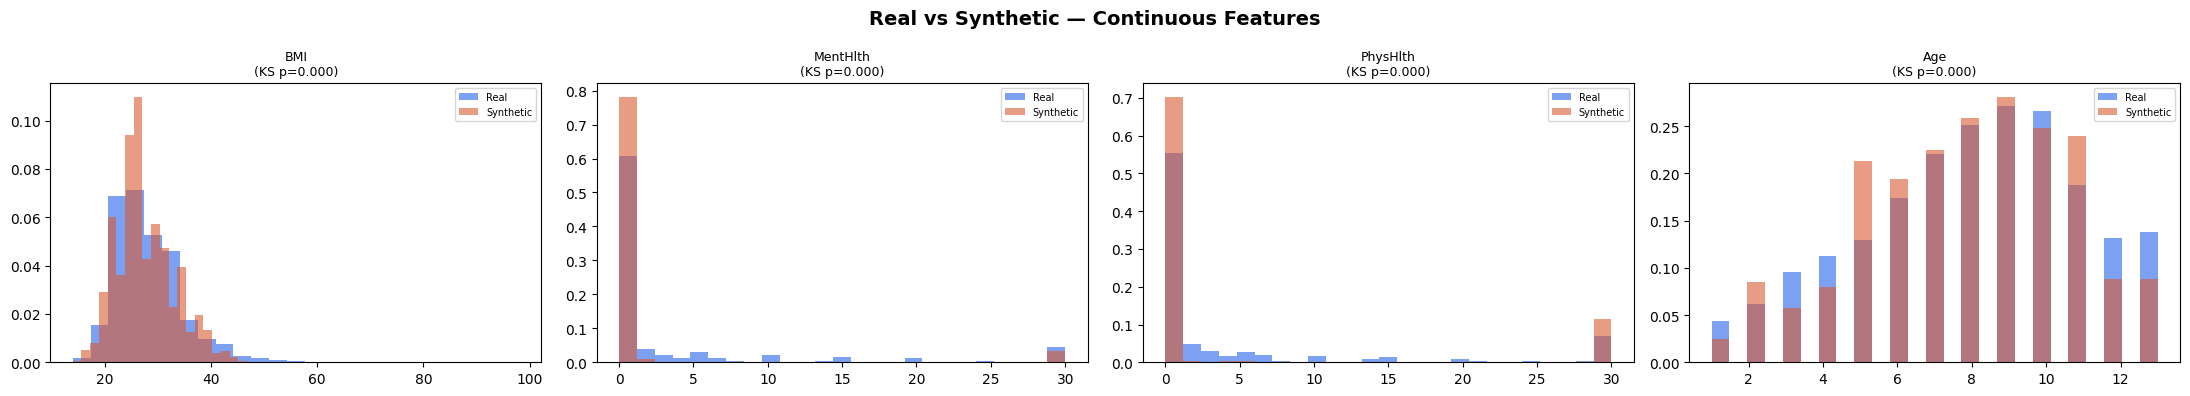

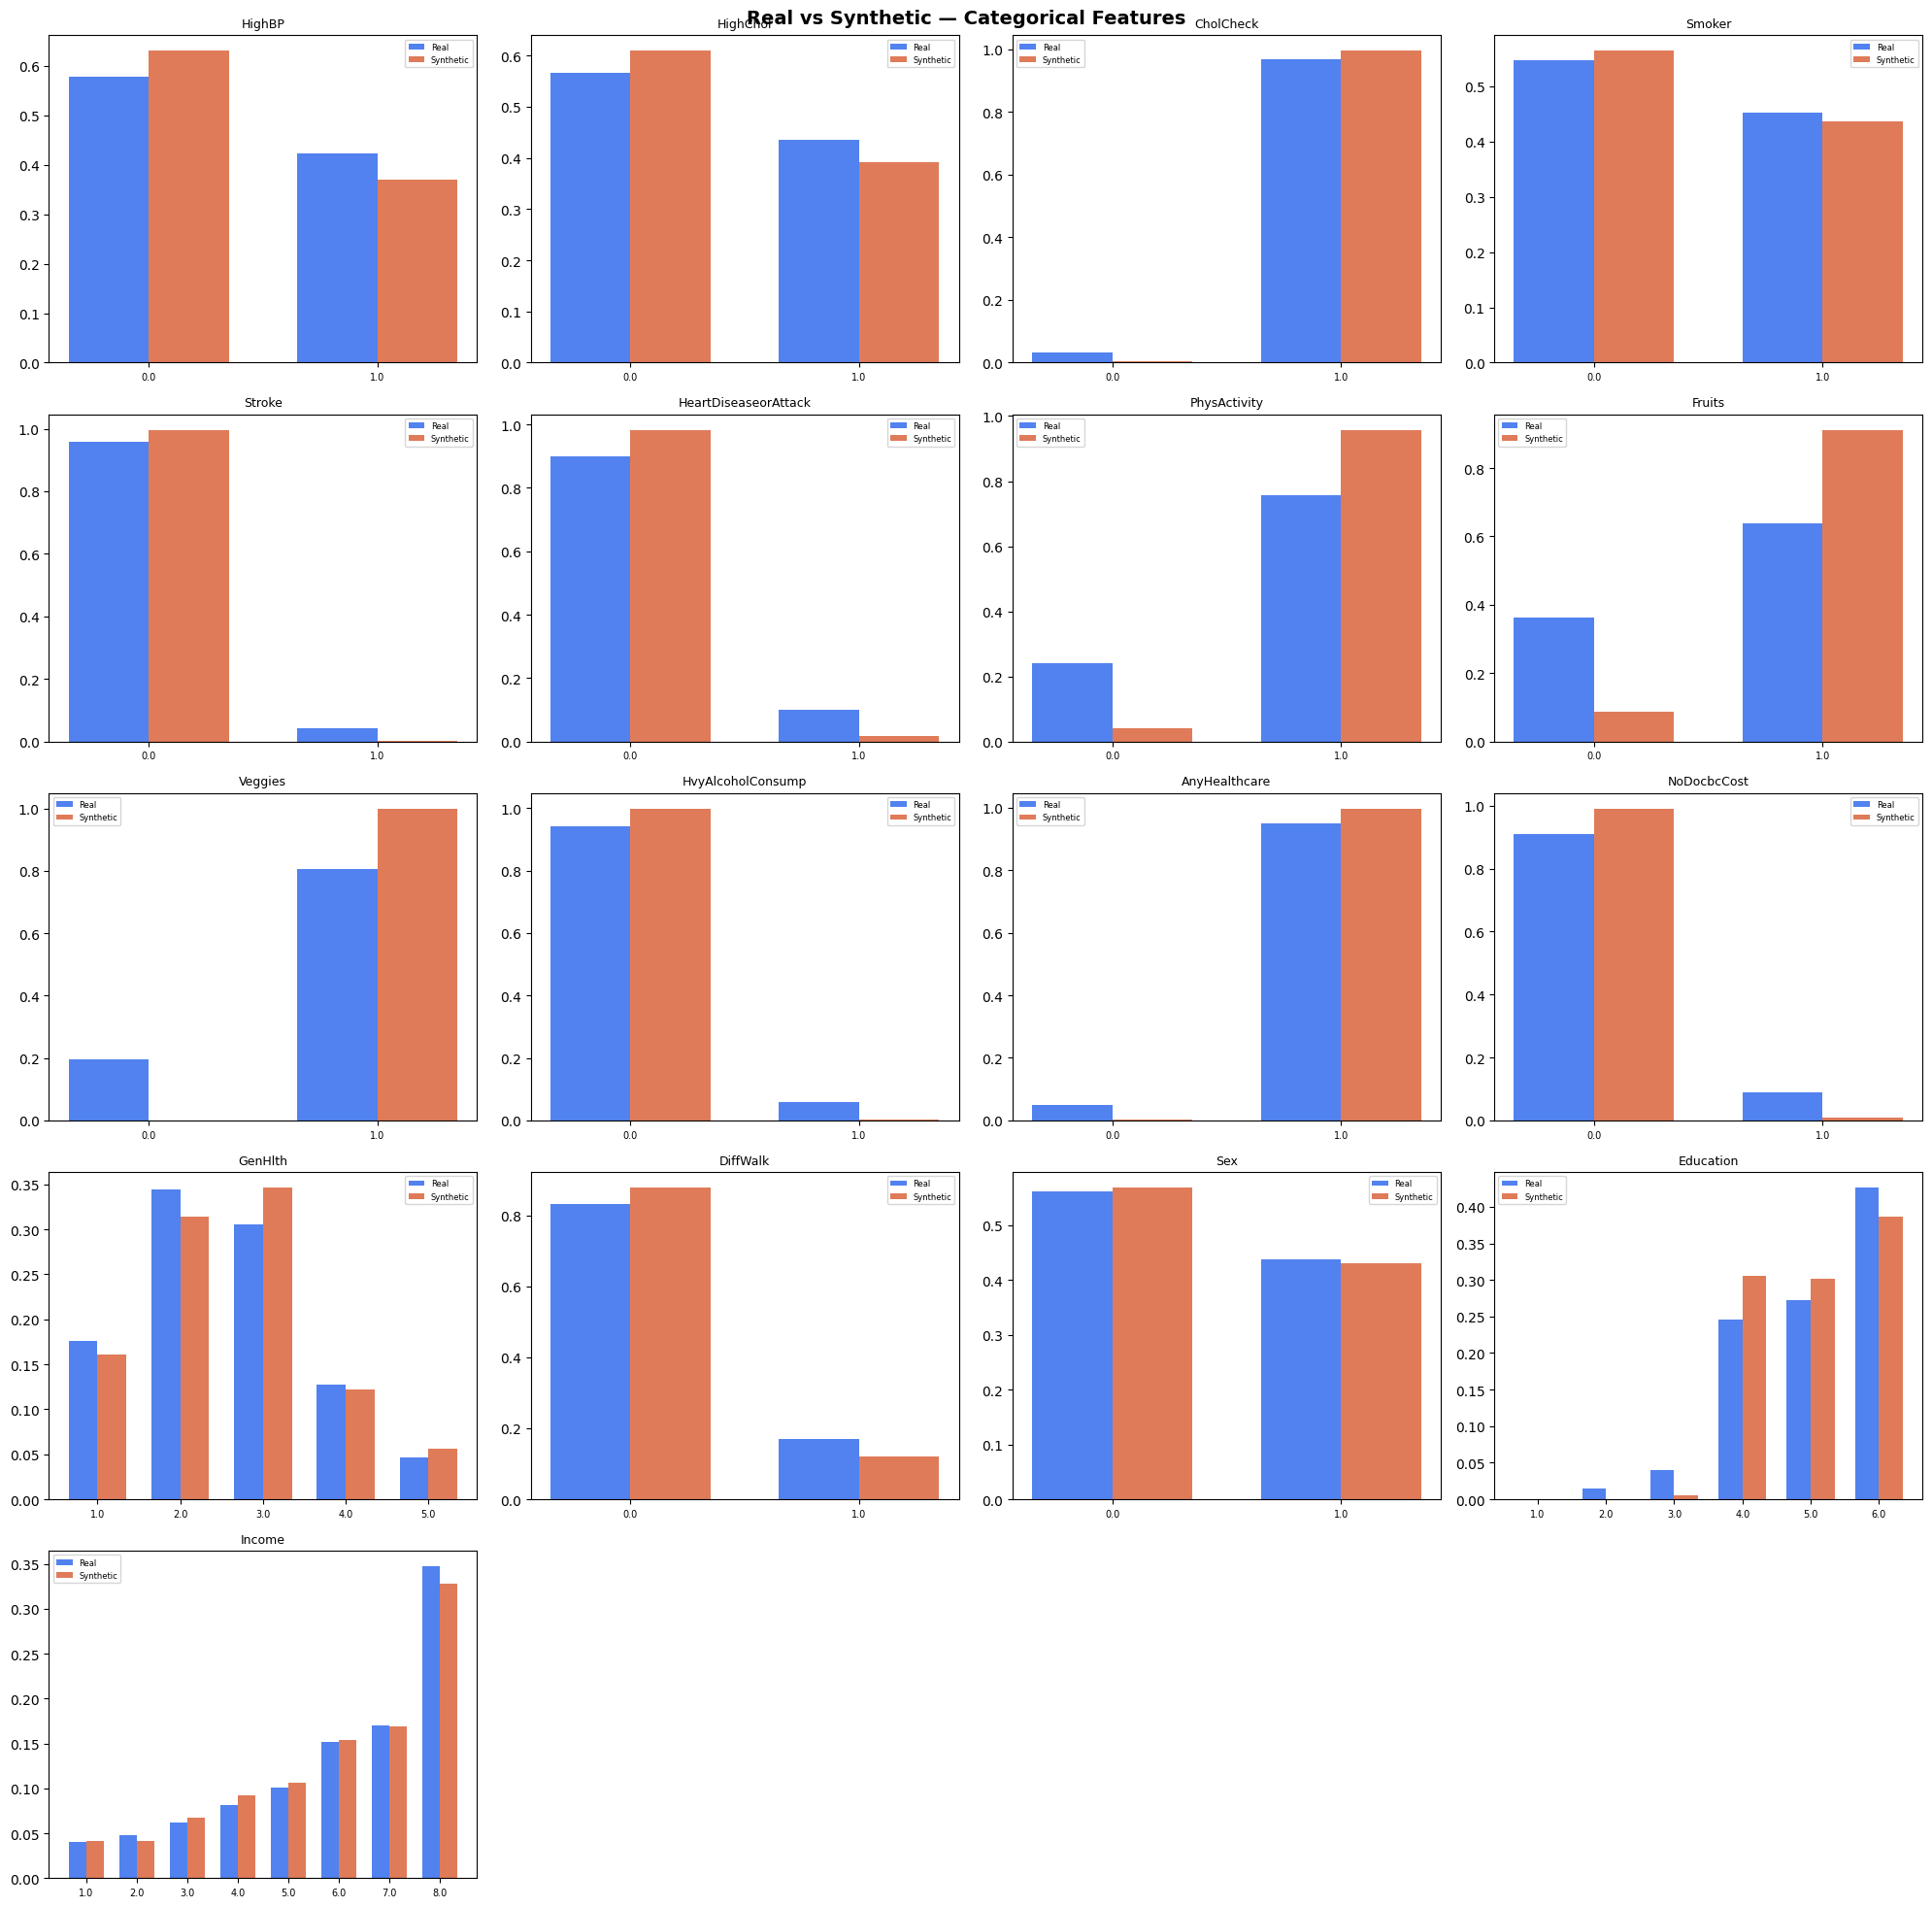

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

features = [c for c in data.columns if c != "target"]

# Auto-detect continuous vs categorical based on unique values
continuous = [c for c in features if data[c].nunique() > 10]
categorical = [c for c in features if data[c].nunique() <= 10]

print(f"Continuous features ({len(continuous)}): {continuous}")
print(f"Categorical features ({len(categorical)}): {categorical}")
print()

print("=" * 70)
print(f"{'Feature':<20} {'KS Stat':>10} {'KS p-value':>12} {'Wasserstein':>12}  Verdict")
print("=" * 70)

ks_results = {}
for feat in features:
    ks_stat, ks_pval = ks_2samp(train_real[feat], synthetic_data[feat])
    wd = wasserstein_distance(train_real[feat], synthetic_data[feat])
    ks_results[feat] = {"ks_stat": ks_stat, "ks_pval": ks_pval, "wd": wd}
    mark = "GOOD" if ks_pval > 0.05 else "DIVERGENT ✗"
    print(f"{feat:<20} {ks_stat:>10.4f} {ks_pval:>12.4f} {wd:>12.4f}  {mark}")

# ── Continuous feature distributions ──
n_cont = len(continuous)
if n_cont > 0:
    n_rows_c = (n_cont + 4) // 5
    fig, axes = plt.subplots(n_rows_c, min(n_cont, 5), figsize=(22, 4 * n_rows_c))
    if n_cont == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)
    fig.suptitle("Real vs Synthetic — Continuous Features", fontsize=14, fontweight="bold")
    for i, feat in enumerate(continuous):
        r, c = i // 5, i % 5
        ax = axes[r][c] if n_rows_c > 1 or n_cont > 1 else axes[0][0]
        ax.hist(train_real[feat], bins=25, alpha=0.6, color="#2563EB", label="Real", density=True)
        ax.hist(synthetic_data[feat], bins=25, alpha=0.6, color="#D85A30", label="Synthetic", density=True)
        ax.set_title(f"{feat}\n(KS p={ks_results[feat]['ks_pval']:.3f})", fontsize=9)
        ax.legend(fontsize=7)
    # Hide unused axes
    for i in range(n_cont, n_rows_c * min(n_cont, 5)):
        r, c = i // 5, i % 5
        if r < axes.shape[0] and c < axes.shape[1]:
            axes[r][c].set_visible(False)
    plt.tight_layout()
    plt.show()

# ── Categorical feature distributions ──
n_cat = len(categorical)
if n_cat > 0:
    n_cols_plot = 4
    n_rows_cat = (n_cat + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_cat, n_cols_plot, figsize=(20, 4 * n_rows_cat))
    axes = np.atleast_2d(axes)
    fig.suptitle("Real vs Synthetic — Categorical Features", fontsize=14, fontweight="bold")
    for idx, feat in enumerate(categorical):
        ax = axes[idx // n_cols_plot][idx % n_cols_plot]
        real_vc = train_real[feat].value_counts(normalize=True).sort_index()
        syn_vc = synthetic_data[feat].value_counts(normalize=True).sort_index()
        all_vals = sorted(set(real_vc.index) | set(syn_vc.index))
        x = np.arange(len(all_vals))
        w = 0.35
        ax.bar(x - w/2, [real_vc.get(v, 0) for v in all_vals], w, color="#2563EB", label="Real", alpha=0.8)
        ax.bar(x + w/2, [syn_vc.get(v, 0) for v in all_vals], w, color="#D85A30", label="Synthetic", alpha=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in all_vals], fontsize=7)
        ax.legend(fontsize=6)
    # Hide unused axes
    for idx in range(n_cat, n_rows_cat * n_cols_plot):
        axes[idx // n_cols_plot][idx % n_cols_plot].set_visible(False)
    plt.tight_layout()
    plt.show()


Using top 12 features for correlation matrices: ['BMI', 'GenHlth', 'HighBP', 'Age', 'PhysHlth', 'Income', 'HighChol', 'DiffWalk', 'HeartDiseaseorAttack', 'MentHlth', 'Education', 'Sex']
Cramér's V Fidelity Score (mean |diff|): 0.0885   (target: < 0.08)
Max difference: 0.5141


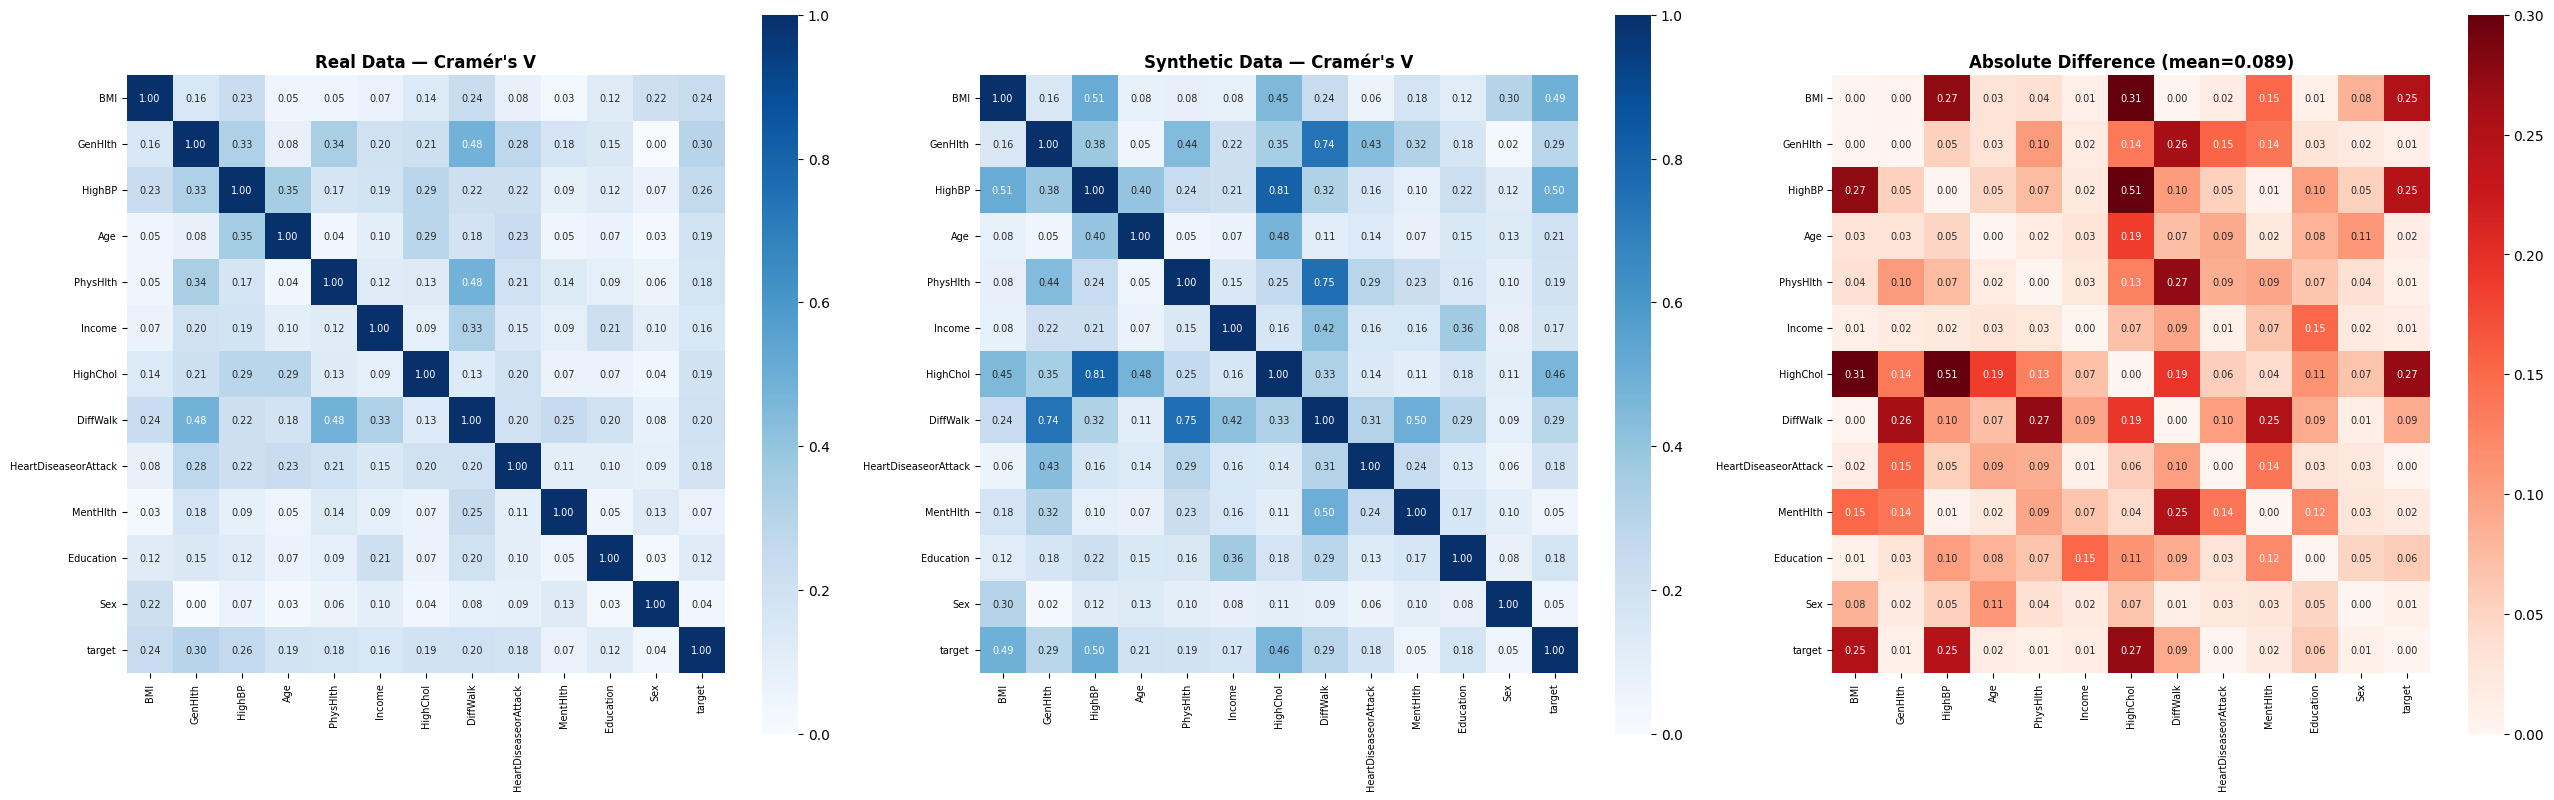

In [5]:
import seaborn as sns
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Bias-corrected Cramér's V."""
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

def build_cramers_matrix(df, cols):
    n = len(cols)
    mat = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
    for i in cols:
        for j in cols:
            mat.loc[i, j] = cramers_v(df[i], df[j])
    return mat

# Use top 12 features (by RF importance) + target to keep heatmap readable
from sklearn.ensemble import RandomForestClassifier as _RFC
_qrf = _RFC(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
_qrf.fit(train_real.drop("target", axis=1), train_real["target"])
_imp = pd.Series(_qrf.feature_importances_, index=features).sort_values(ascending=False)
top_feats = _imp.head(12).index.tolist()
cv_cols = top_feats + ["target"]
print(f"Using top {len(top_feats)} features for correlation matrices: {top_feats}")

# Build matrices
real_cv = build_cramers_matrix(train_real, cv_cols)
synth_cv = build_cramers_matrix(synthetic_data, cv_cols)
diff_cv = (real_cv - synth_cv).abs()

# Summary stats
mask_idx = np.triu_indices_from(diff_cv.values, k=1)
mean_diff = diff_cv.values[mask_idx].mean()
max_diff = diff_cv.values[mask_idx].max()

print(f"Cramér's V Fidelity Score (mean |diff|): {mean_diff:.4f}   (target: < 0.08)")
print(f"Max difference: {max_diff:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

sns.heatmap(real_cv.astype(float), annot=True, fmt=".2f", cmap="Blues",
            ax=axes[0], vmin=0, vmax=1, annot_kws={"size": 7}, square=True)
axes[0].set_title("Real Data — Cramér's V", fontweight="bold", fontsize=12)
axes[0].tick_params(labelsize=7)

sns.heatmap(synth_cv.astype(float), annot=True, fmt=".2f", cmap="Blues",
            ax=axes[1], vmin=0, vmax=1, annot_kws={"size": 7}, square=True)
axes[1].set_title("Synthetic Data — Cramér's V", fontweight="bold", fontsize=12)
axes[1].tick_params(labelsize=7)

sns.heatmap(diff_cv.astype(float), annot=True, fmt=".2f", cmap="Reds",
            ax=axes[2], vmin=0, vmax=0.3, annot_kws={"size": 7}, square=True)
axes[2].set_title(f"Absolute Difference (mean={mean_diff:.3f})", fontweight="bold", fontsize=12)
axes[2].tick_params(labelsize=7)

plt.tight_layout()
plt.show()


Mutual Information Fidelity Score (mean |diff|): 0.0297


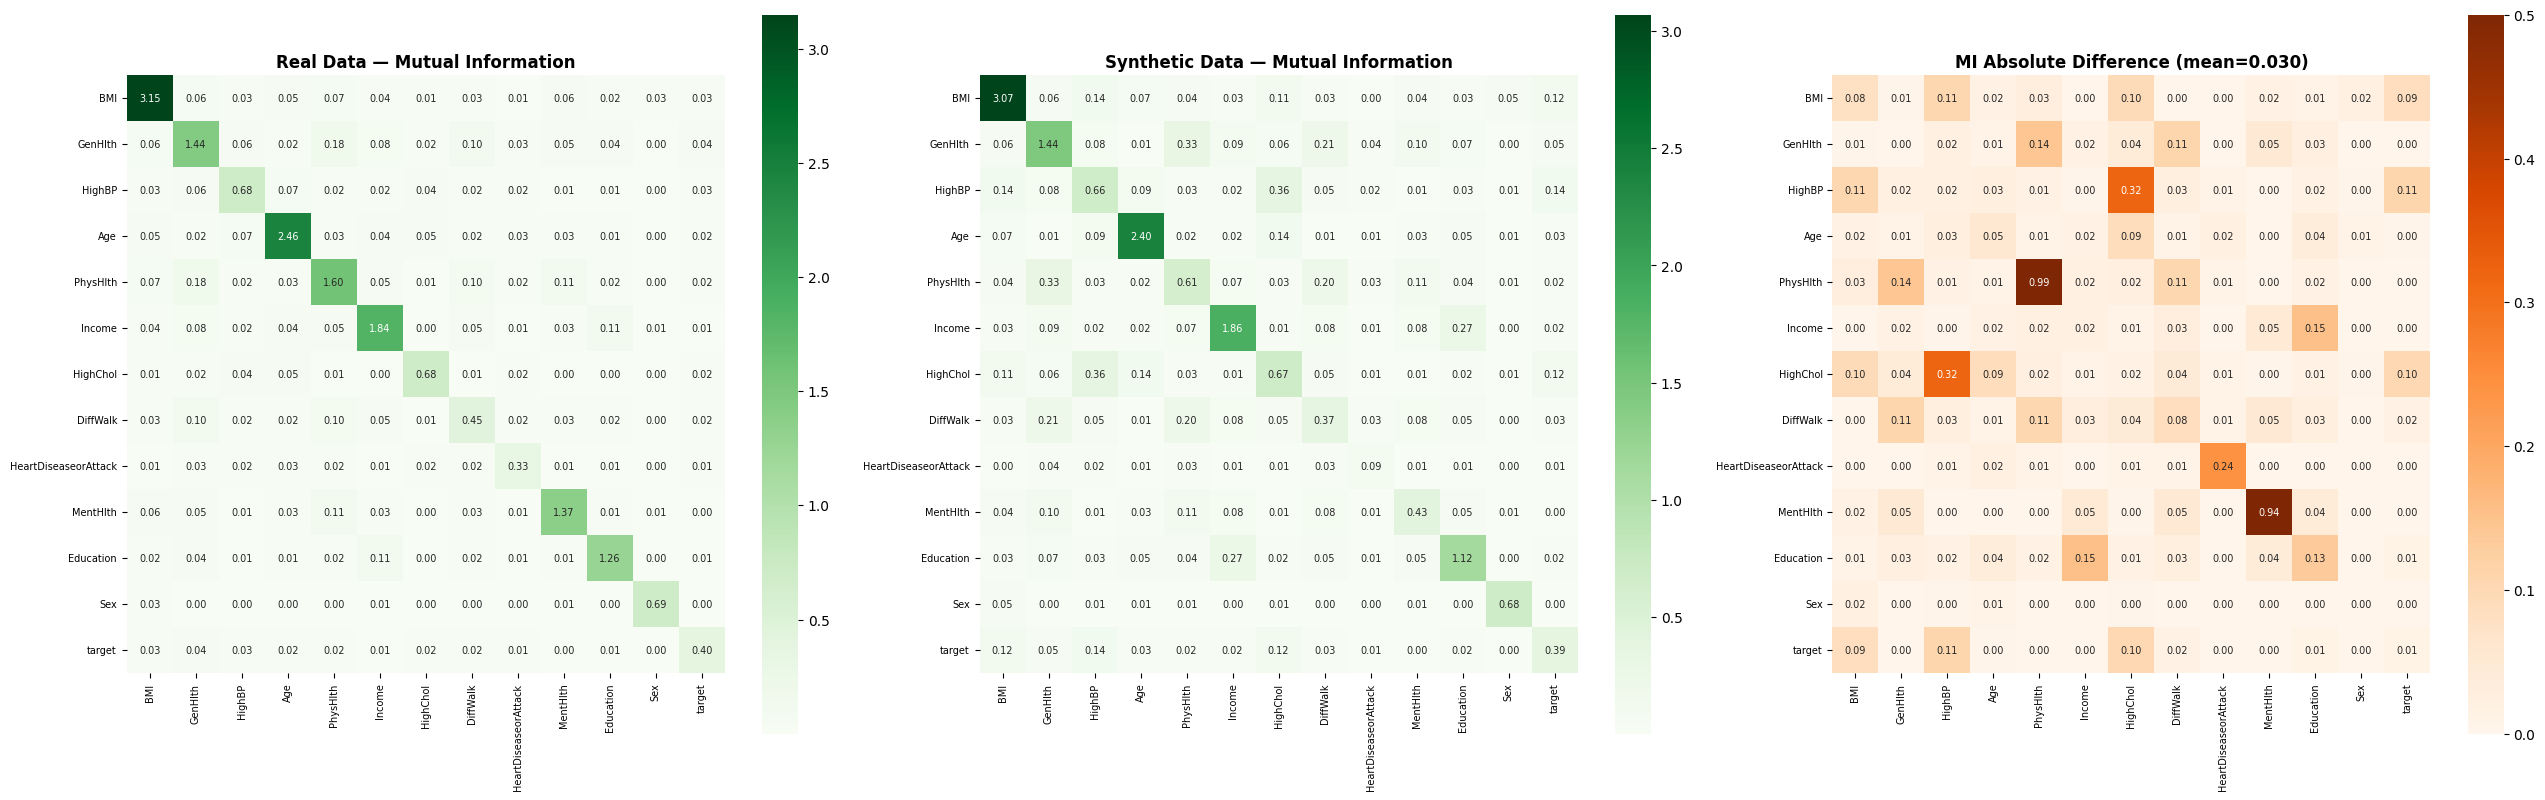

In [6]:
from sklearn.metrics import mutual_info_score

def build_mi_matrix(df, cols):
    n = len(cols)
    mat = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
    for i in cols:
        for j in cols:
            mat.loc[i, j] = mutual_info_score(df[i], df[j])
    return mat

real_mi = build_mi_matrix(train_real, cv_cols)
synth_mi = build_mi_matrix(synthetic_data, cv_cols)
diff_mi = (real_mi - synth_mi).abs()
mean_mi_diff = diff_mi.values[mask_idx].mean()

print(f"Mutual Information Fidelity Score (mean |diff|): {mean_mi_diff:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

sns.heatmap(real_mi.astype(float), annot=True, fmt=".2f", cmap="Greens",
            ax=axes[0], annot_kws={"size": 7}, square=True)
axes[0].set_title("Real Data — Mutual Information", fontweight="bold", fontsize=12)
axes[0].tick_params(labelsize=7)

sns.heatmap(synth_mi.astype(float), annot=True, fmt=".2f", cmap="Greens",
            ax=axes[1], annot_kws={"size": 7}, square=True)
axes[1].set_title("Synthetic Data — Mutual Information", fontweight="bold", fontsize=12)
axes[1].tick_params(labelsize=7)

sns.heatmap(diff_mi.astype(float), annot=True, fmt=".2f", cmap="Oranges",
            ax=axes[2], vmin=0, vmax=0.5, annot_kws={"size": 7}, square=True)
axes[2].set_title(f"MI Absolute Difference (mean={mean_mi_diff:.3f})", fontweight="bold", fontsize=12)
axes[2].tick_params(labelsize=7)

plt.tight_layout()
plt.show()


Metric       TRTR (Real)      TSTR (Synthetic)   Gap       
accuracy     0.8450           0.8405             +0.0045  ✓
f1           0.3800           0.4125             -0.0325  ✓
auc_roc      0.8140           0.7955             +0.0185  ✓

── TRTR Report ──
              precision    recall  f1-score   support

 No Diabetes       0.90      0.93      0.91      1721
    Diabetes       0.43      0.34      0.38       279

    accuracy                           0.84      2000
   macro avg       0.66      0.63      0.65      2000
weighted avg       0.83      0.84      0.84      2000

── TSTR Report ──
              precision    recall  f1-score   support

 No Diabetes       0.90      0.91      0.91      1721
    Diabetes       0.42      0.40      0.41       279

    accuracy                           0.84      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.84      0.84      0.84      2000



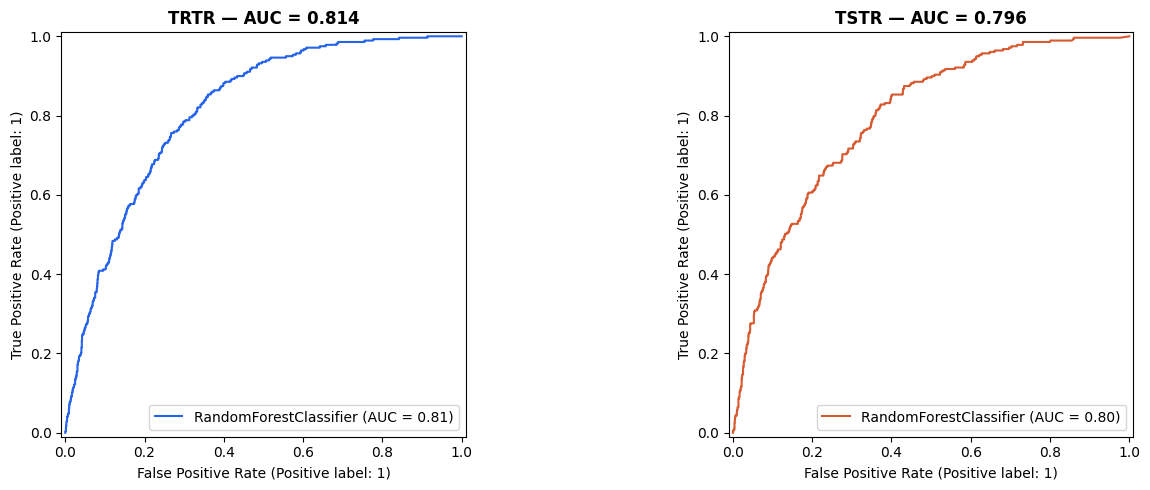

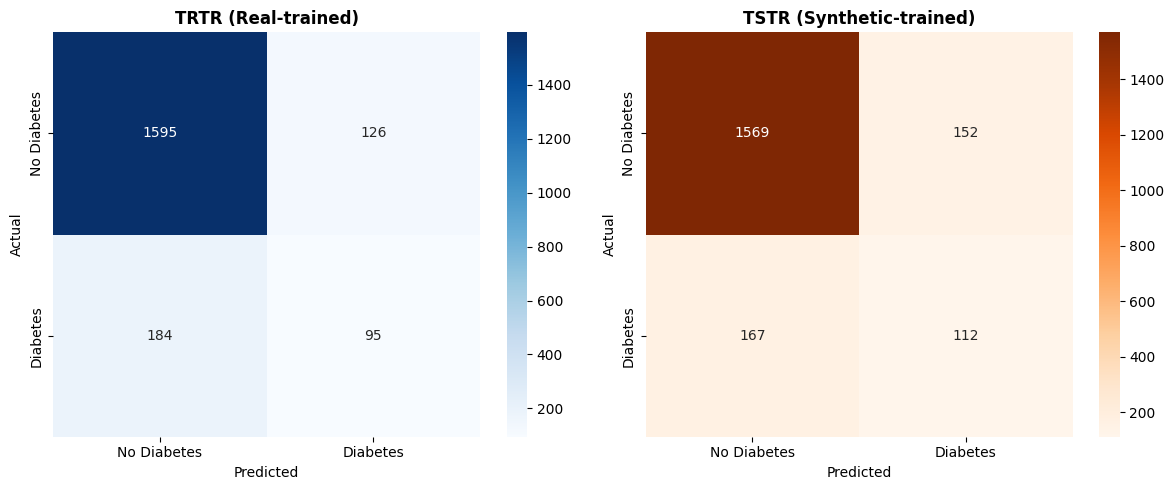

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay)

X_train_real = train_real.drop("target", axis=1)
y_train_real = train_real["target"]
X_test_real = test_real.drop("target", axis=1)
y_test_real = test_real["target"]
X_synth = synthetic_data.drop("target", axis=1)
y_synth = synthetic_data["target"]

# ── TRTR: Train on Real, Test on Real (baseline) ──
rf_real = RandomForestClassifier(
    n_estimators=200, min_samples_split=5, min_samples_leaf=2,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
)
rf_real.fit(X_train_real, y_train_real)
pred_real = rf_real.predict(X_test_real)
proba_real = rf_real.predict_proba(X_test_real)[:, 1]

# ── TSTR: Train on Synthetic, Test on Real ──
rf_synth = RandomForestClassifier(
    n_estimators=200, min_samples_split=5, min_samples_leaf=2,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
)
rf_synth.fit(X_synth, y_synth)
pred_synth = rf_synth.predict(X_test_real)
proba_synth = rf_synth.predict_proba(X_test_real)[:, 1]

# ── Compare ──
results = {
    "TRTR": {
        "accuracy": accuracy_score(y_test_real, pred_real),
        "f1": f1_score(y_test_real, pred_real),
        "auc_roc": roc_auc_score(y_test_real, proba_real),
    },
    "TSTR": {
        "accuracy": accuracy_score(y_test_real, pred_synth),
        "f1": f1_score(y_test_real, pred_synth),
        "auc_roc": roc_auc_score(y_test_real, proba_synth),
    },
}

print("=" * 60)
print(f"{'Metric':<12} {'TRTR (Real)':<16} {'TSTR (Synthetic)':<18} {'Gap':<10}")
print("=" * 60)
for m in ["accuracy", "f1", "auc_roc"]:
    trtr_val = results["TRTR"][m]
    tstr_val = results["TSTR"][m]
    gap = trtr_val - tstr_val
    ok = "✓" if abs(gap) < 0.05 else "✗"
    print(f"{m:<12} {trtr_val:<16.4f} {tstr_val:<18.4f} {gap:>+.4f}  {ok}")
print("=" * 60)

print("\n── TRTR Report ──")
print(classification_report(y_test_real, pred_real, target_names=["No Diabetes", "Diabetes"]))
print("── TSTR Report ──")
print(classification_report(y_test_real, pred_synth, target_names=["No Diabetes", "Diabetes"]))

# ── ROC Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_estimator(rf_real, X_test_real, y_test_real, ax=axes[0], color="#2563EB")
axes[0].set_title(f"TRTR — AUC = {results['TRTR']['auc_roc']:.3f}", fontweight="bold")
RocCurveDisplay.from_estimator(rf_synth, X_test_real, y_test_real, ax=axes[1], color="#D85A30")
axes[1].set_title(f"TSTR — AUC = {results['TSTR']['auc_roc']:.3f}", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title, cmap in [
    (axes[0], pred_real, "TRTR (Real-trained)", "Blues"),
    (axes[1], pred_synth, "TSTR (Synthetic-trained)", "Oranges"),
]:
    cm = confusion_matrix(y_test_real, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["No Diabetes","Diabetes"],
                yticklabels=["No Diabetes","Diabetes"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

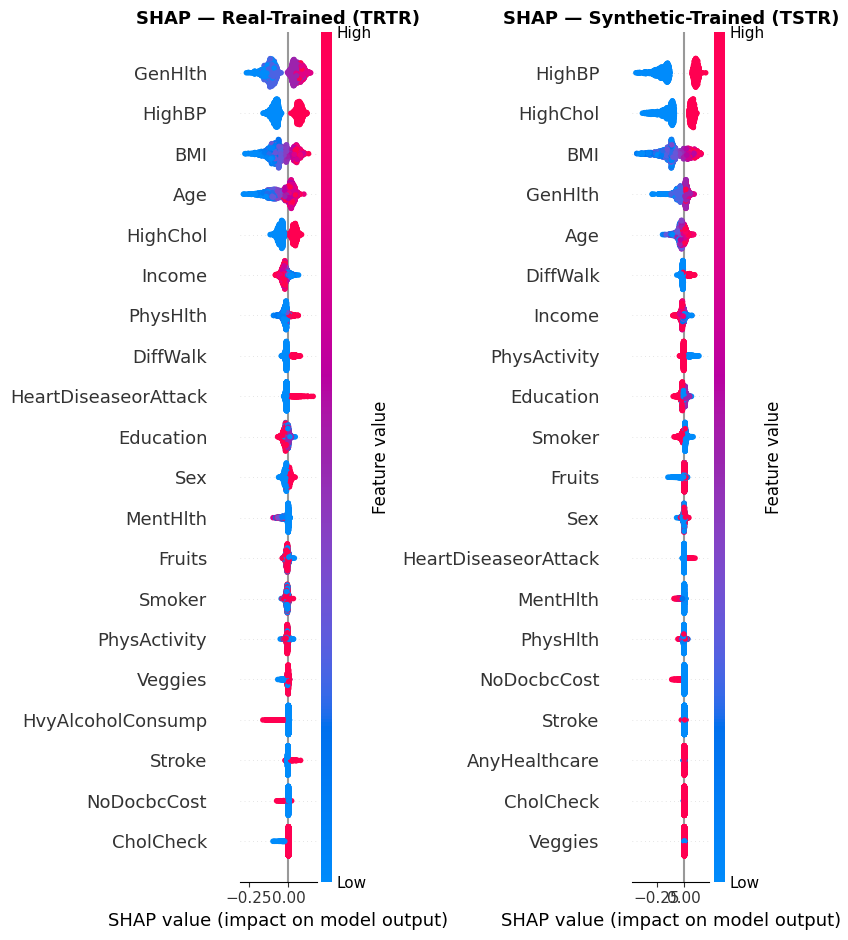

Feature      |SHAP| Real    |SHAP| Synth   Real Rank  Synth Rank  Shift
GenHlth      0.0889         0.0447         1          4           ↓3  ← TVAE distorted
HighBP       0.0784         0.1641         2          1           ↑1
BMI          0.0735         0.1176         3          3           —
Age          0.0566         0.0320         4          5           ↓1
HighChol     0.0465         0.1225         5          2           ↑3  ← TVAE distorted
Income       0.0264         0.0205         6          7           ↓1
PhysHlth     0.0224         0.0060         7          15          ↓8  ← TVAE distorted
DiffWalk     0.0191         0.0219         8          6           ↑2
HeartDiseaseorAttack 0.0170         0.0070         9          13          ↓4  ← TVAE distorted
Education    0.0162         0.0198         10         9           ↑1
Sex          0.0152         0.0076         11         12          ↓1
MentHlth     0.0138         0.0069         12         14          ↓2
Fruits       0.0094  

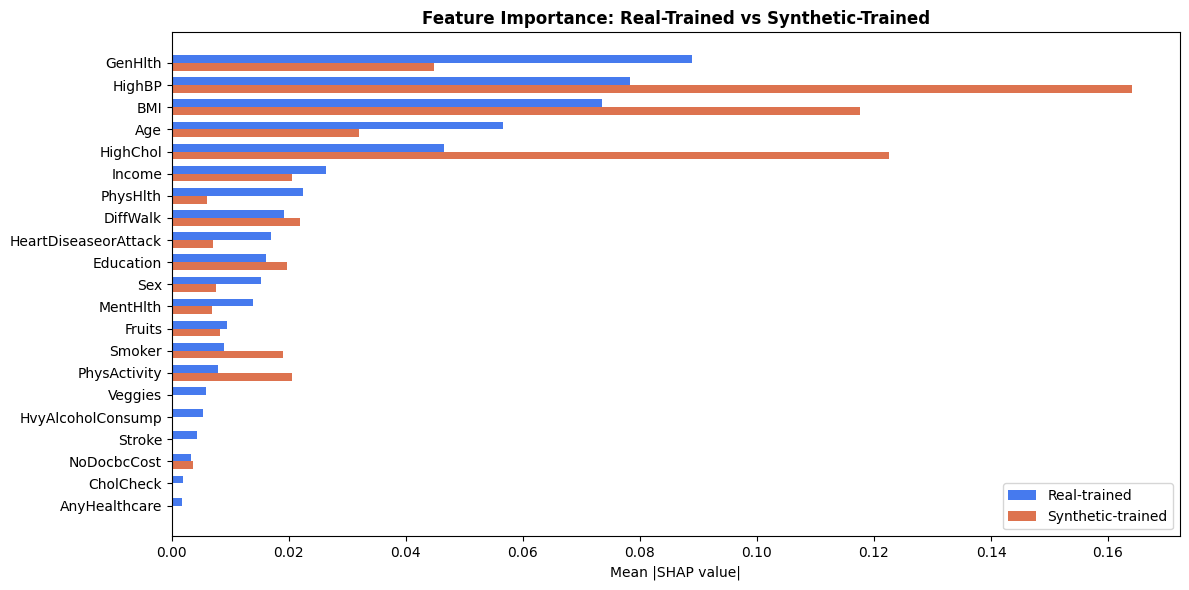

In [8]:
import shap

# ── SHAP for real-trained model ──
explainer_real = shap.TreeExplainer(rf_real)
shap_vals_real = explainer_real.shap_values(X_test_real)

if isinstance(shap_vals_real, list):
    sv_real = shap_vals_real[1]
elif len(shap_vals_real.shape) == 3:
    sv_real = shap_vals_real[:, :, 1]
else:
    sv_real = shap_vals_real

# ── SHAP for synthetic-trained model ──
explainer_synth = shap.TreeExplainer(rf_synth)
shap_vals_synth = explainer_synth.shap_values(X_test_real)

if isinstance(shap_vals_synth, list):
    sv_synth = shap_vals_synth[1]
elif len(shap_vals_synth.shape) == 3:
    sv_synth = shap_vals_synth[:, :, 1]
else:
    sv_synth = shap_vals_synth

# ── Side-by-side beeswarm plots ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plt.sca(axes[0])
shap.summary_plot(sv_real, X_test_real, plot_type="dot", show=False)
axes[0].set_title("SHAP — Real-Trained (TRTR)", fontweight="bold", fontsize=13)

plt.sca(axes[1])
shap.summary_plot(sv_synth, X_test_real, plot_type="dot", show=False)
axes[1].set_title("SHAP — Synthetic-Trained (TSTR)", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.show()

# ── Rank comparison table ──
mean_real = pd.Series(np.abs(sv_real).mean(axis=0), index=X_test_real.columns).sort_values(ascending=False)
mean_synth = pd.Series(np.abs(sv_synth).mean(axis=0), index=X_test_real.columns).sort_values(ascending=False)

rank_r = mean_real.rank(ascending=False).astype(int)
rank_s = mean_synth.rank(ascending=False).astype(int)

print("=" * 65)
print(f"{'Feature':<12} {'|SHAP| Real':<14} {'|SHAP| Synth':<14} {'Real Rank':<10} {'Synth Rank':<11} Shift")
print("=" * 65)
for feat in mean_real.index:
    shift = int(rank_r[feat] - rank_s[feat])
    arrow = "—" if shift == 0 else f"↑{abs(shift)}" if shift > 0 else f"↓{abs(shift)}"
    flag = "  ← TVAE distorted" if abs(shift) >= 3 else ""
    print(f"{feat:<12} {mean_real[feat]:<14.4f} {mean_synth[feat]:<14.4f} {int(rank_r[feat]):<10} {int(rank_s[feat]):<11} {arrow}{flag}")
print("=" * 65)

# ── Bar chart comparison ──
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(mean_real))
w = 0.35
ax.barh(x - w/2, mean_real.values, w, color="#2563EB", label="Real-trained", alpha=0.85)
ax.barh(x + w/2, mean_synth.reindex(mean_real.index).values, w, color="#D85A30", label="Synthetic-trained", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(mean_real.index)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature Importance: Real-Trained vs Synthetic-Trained", fontweight="bold")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

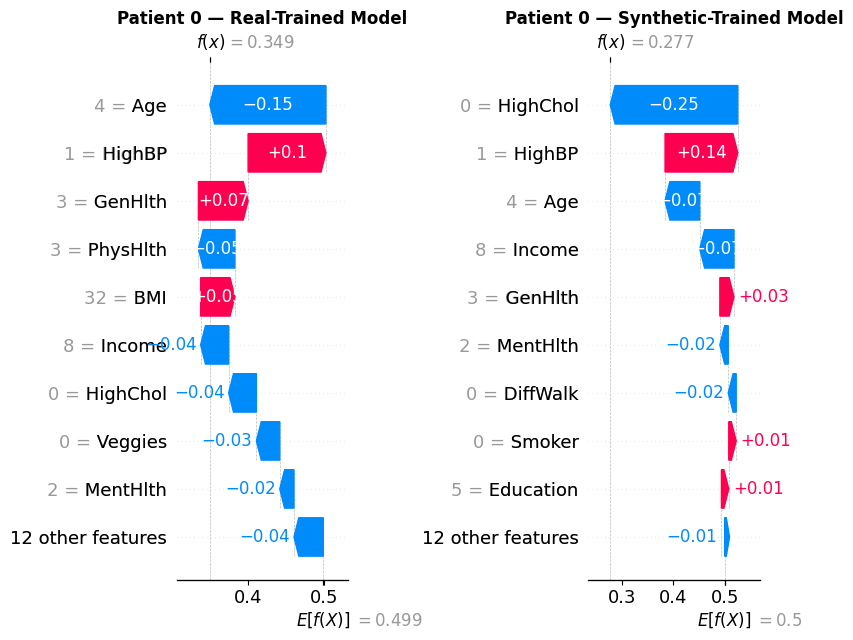

In [9]:
patient_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
ev_real = explainer_real.expected_value
base_real = ev_real[1] if isinstance(ev_real, (list, np.ndarray)) else ev_real
shap.plots.waterfall(
    shap.Explanation(
        values=sv_real[patient_idx],
        base_values=base_real,
        data=X_test_real.iloc[patient_idx],
        feature_names=list(X_test_real.columns)
    ), show=False
)
axes[0].set_title("Patient 0 — Real-Trained Model", fontweight="bold")

plt.sca(axes[1])
ev_synth = explainer_synth.expected_value
base_synth = ev_synth[1] if isinstance(ev_synth, (list, np.ndarray)) else ev_synth
shap.plots.waterfall(
    shap.Explanation(
        values=sv_synth[patient_idx],
        base_values=base_synth,
        data=X_test_real.iloc[patient_idx],
        feature_names=list(X_test_real.columns)
    ), show=False
)
axes[1].set_title("Patient 0 — Synthetic-Trained Model", fontweight="bold")

plt.tight_layout()
plt.show()

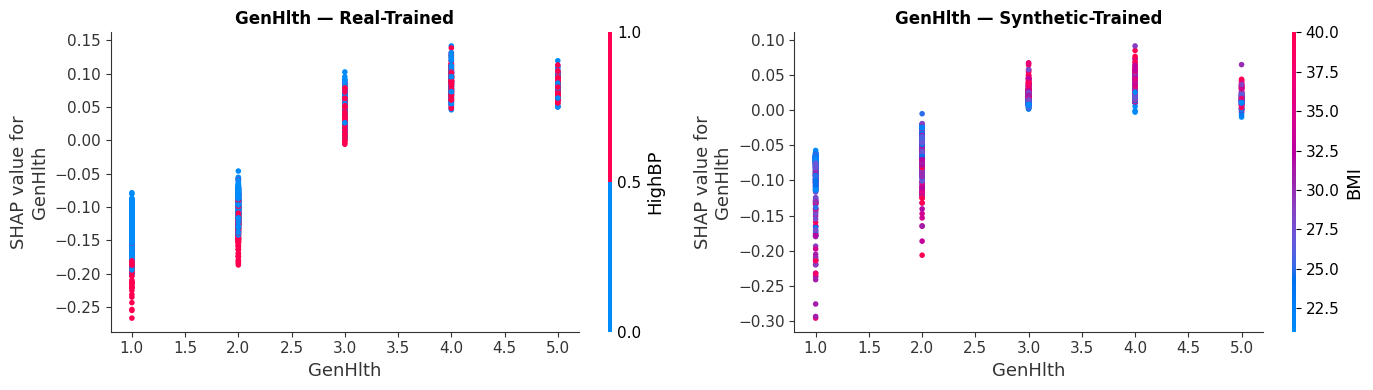

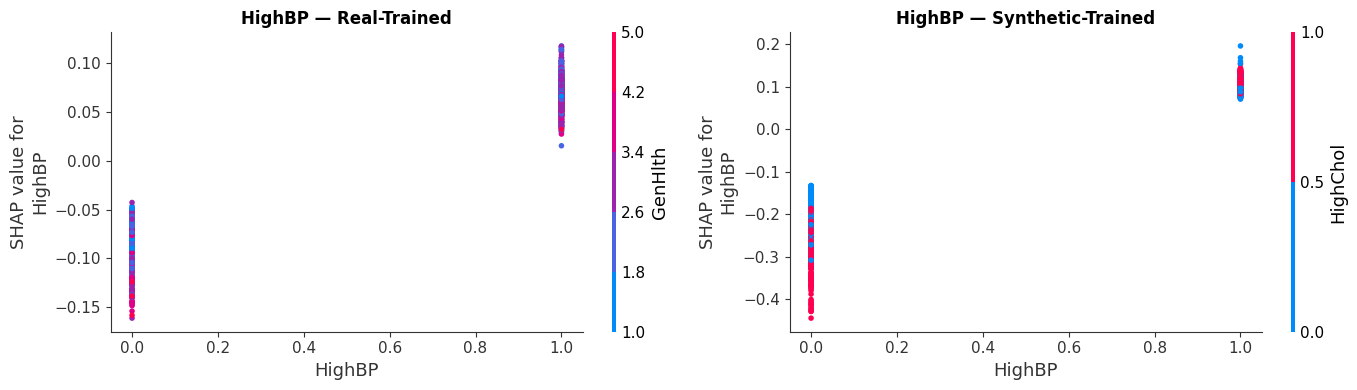

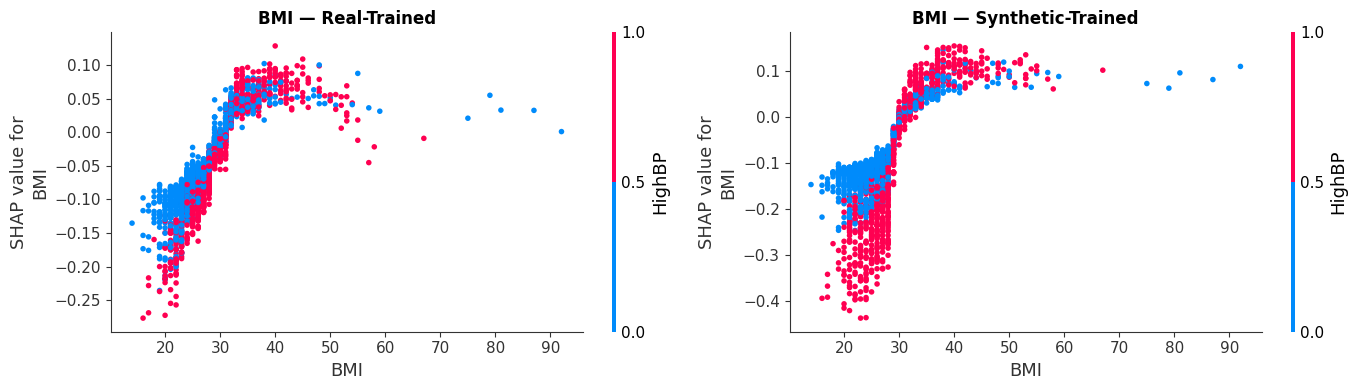

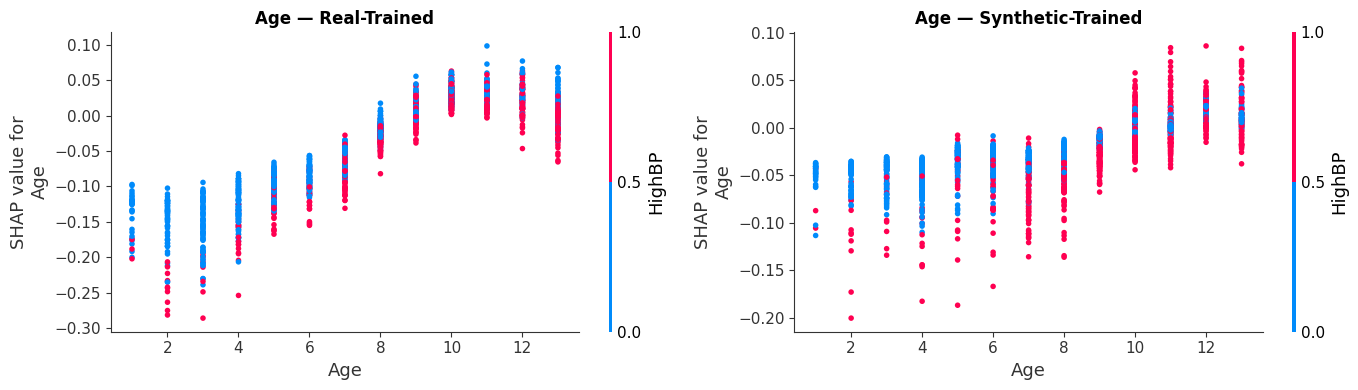

In [10]:
top4 = mean_real.index[:4].tolist()

for feat in top4:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plt.sca(axes[0])
    shap.dependence_plot(feat, sv_real, X_test_real, ax=axes[0], show=False)
    axes[0].set_title(f"{feat} — Real-Trained", fontweight="bold")

    plt.sca(axes[1])
    shap.dependence_plot(feat, sv_synth, X_test_real, ax=axes[1], show=False)
    axes[1].set_title(f"{feat} — Synthetic-Trained", fontweight="bold")

    plt.tight_layout()
    plt.show()

In [11]:
print("╔" + "═"*62 + "╗")
print("║        TRIALFORGE — CDC BRFSS 10K — RESULTS SUMMARY                       ║")
print("╠" + "═"*62 + "╣")
print(f"║  Cramér's V Fidelity (mean |diff|):  {mean_diff:<24.4f} ║")
print(f"║  Mutual Info Fidelity (mean |diff|):  {mean_mi_diff:<23.4f} ║")
print("╠" + "═"*62 + "╣")
print(f"║  TRTR Accuracy:  {results['TRTR']['accuracy']:<43.4f} ║")
print(f"║  TSTR Accuracy:  {results['TSTR']['accuracy']:<43.4f} ║")
print(f"║  Accuracy Gap:   {results['TRTR']['accuracy'] - results['TSTR']['accuracy']:>+.4f}{'':<38} ║")
print("╠" + "═"*62 + "╣")
print(f"║  TRTR AUC-ROC:   {results['TRTR']['auc_roc']:<43.4f} ║")
print(f"║  TSTR AUC-ROC:   {results['TSTR']['auc_roc']:<43.4f} ║")
print(f"║  AUC Gap:        {results['TRTR']['auc_roc'] - results['TSTR']['auc_roc']:>+.4f}{'':<38} ║")
print("╠" + "═"*62 + "╣")
print(f"║  TRTR F1:        {results['TRTR']['f1']:<43.4f} ║")
print(f"║  TSTR F1:        {results['TSTR']['f1']:<43.4f} ║")
print(f"║  F1 Gap:         {results['TRTR']['f1'] - results['TSTR']['f1']:>+.4f}{'':<38} ║")
print("╠" + "═"*62 + "╣")
print("║  SHAP Rank Shifts:                                          ║")
for feat in mean_real.index:
    shift = int(rank_r[feat] - rank_s[feat])
    arrow = "—" if shift == 0 else f"↑{abs(shift)}" if shift > 0 else f"↓{abs(shift)}"
    line = f"║    {feat:<10}  Real #{int(rank_r[feat]):<3} → Synth #{int(rank_s[feat]):<3}  ({arrow})"
    print(f"{line:<63} ║")
print("╚" + "═"*62 + "╝")

╔══════════════════════════════════════════════════════════════╗
║        TRIALFORGE — CDC BRFSS 10K — RESULTS SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  Cramér's V Fidelity (mean |diff|):  0.0885                   ║
║  Mutual Info Fidelity (mean |diff|):  0.0297                  ║
╠══════════════════════════════════════════════════════════════╣
║  TRTR Accuracy:  0.8450                                      ║
║  TSTR Accuracy:  0.8405                                      ║
║  Accuracy Gap:   +0.0045                                       ║
╠══════════════════════════════════════════════════════════════╣
║  TRTR AUC-ROC:   0.8140                                      ║
║  TSTR AUC-ROC:   0.7955                                      ║
║  AUC Gap:        +0.0185                                       ║
╠══════════════════════════════════════════════════════════════╣
║  TRTR F1:        0.3800                                      ║
║  TST

In [15]:
from google.colab import files
uploaded = files.upload()

Saving trialforge_moa.py to trialforge_moa.py
Saving trialforge_simulation.py to trialforge_simulation.py


In [16]:
from pathlib import Path
import pickle
import joblib

from trialforge_moa import DrugMoAInput
from trialforge_simulation import (
    build_explanation_summary,
    build_feature_delta_table,
    build_simulation_context,
    choose_demo_patient,
    export_simulation_bundle,
    score_patient_pair,
)

simulation_context = build_simulation_context(train_real)
feature_importances_real = pd.Series(rf_real.feature_importances_, index=X_train_real.columns).sort_values(ascending=False)

moa_info = DrugMoAInput(
    drug_name="GLP-1 Demo",
    moa_summary="Improves glucose control and supports weight loss through appetite regulation.",
    expected_biomarker_effect="Lower fasting glucose, lower BMI, improved cardiometabolic burden.",
    gamma=0.42,
    reasoning_brief="Prototype gamma chosen manually; later this can come from a parser + retrieval + reasoning stack.",
    source_type="manual_demo",
)

print("Simulation context ready.")
print(f"Recovery vector dimensions: {len(simulation_context.recovery_vector)}")
print(f"Default demo gamma: {moa_info.resolved_gamma(simulation_context.default_gamma):.2f}")


Simulation context ready.
Recovery vector dimensions: 21
Default demo gamma: 0.42


In [17]:
trial_patient = choose_demo_patient(test_real, preferred_target=1)
trial_patient_features = trial_patient.drop("target")

trial_result = score_patient_pair(
    patient_row=trial_patient_features,
    context=simulation_context,
    moa_info=moa_info,
    risk_model=rf_real,
)

trial_delta_table = build_feature_delta_table(
    trial_result["baseline_features"],
    trial_result["trial_twin_features"],
)
trial_explanation = build_explanation_summary(trial_result["feature_deltas"], moa_info)

print(f"Drug: {moa_info.drug_name}")
print(f"Gamma: {trial_result['gamma']:.2f}")
print(f"Baseline diabetes risk: {trial_result['baseline_score']:.3f}")
print(f"Trial twin diabetes risk: {trial_result['trial_score']:.3f}")
print(f"Predicted improvement: {trial_result['predicted_improvement']:.3f}")
print()
print(trial_explanation)
print()
trial_delta_table.head(8)


Drug: GLP-1 Demo
Gamma: 0.42
Baseline diabetes risk: 0.743
Trial twin diabetes risk: 0.609
Predicted improvement: 0.134

GLP-1 Demo shifts the patient toward the healthier centroid, with the largest simulated changes in PhysHlth (-1.90), BMI (-1.62), Age (-0.67). The gamma score encodes the assumed intervention strength.



,baseline,trial_twin,delta,abs_delta
PhysHlth,30.0,28.099709,-1.900291,1.900291
BMI,32.0,30.377717,-1.622283,1.622283
Age,5.0,4.334902,-0.665098,0.665098
MentHlth,30.0,29.432821,-0.567179,0.567179
Income,1.0,1.401941,0.401941,0.401941
GenHlth,5.0,4.622888,-0.377112,0.377112
Education,5.0,5.136240,0.136240,0.136240
HighBP,1.0,1.000000,0.000000,0.000000


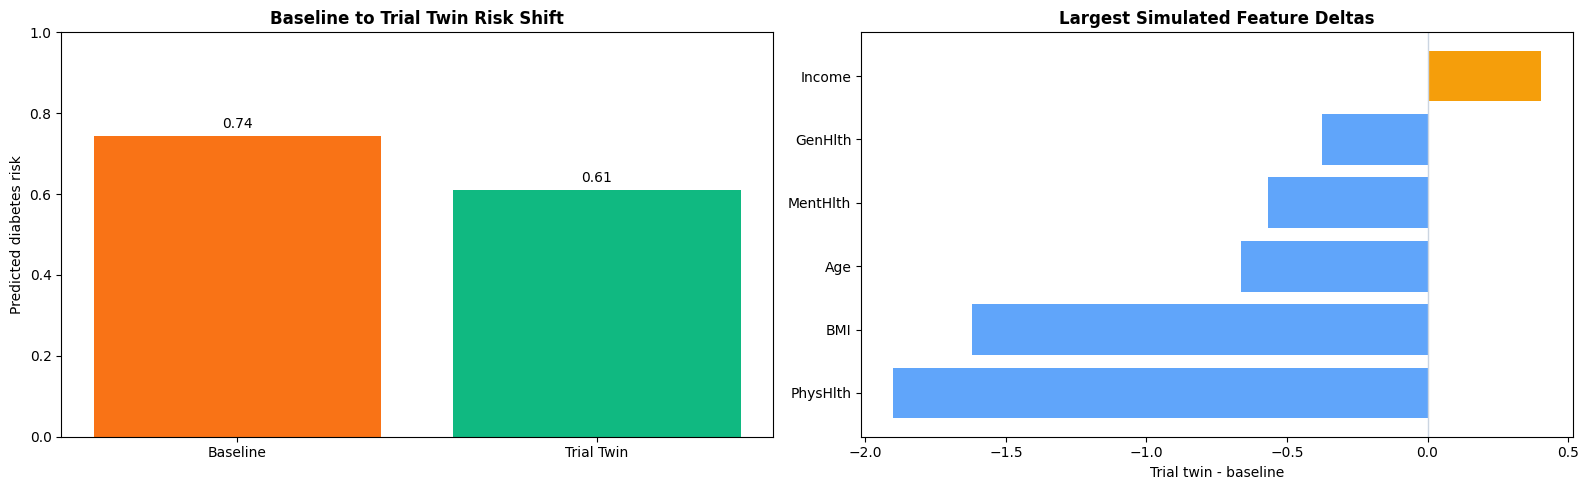

In [18]:
plot_deltas = trial_delta_table.head(6).sort_values("delta")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    ["Baseline", "Trial Twin"],
    [trial_result["baseline_score"], trial_result["trial_score"]],
    color=["#F97316", "#10B981"],
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Predicted diabetes risk")
axes[0].set_title("Baseline to Trial Twin Risk Shift", fontweight="bold")
for idx, score in enumerate([trial_result["baseline_score"], trial_result["trial_score"]]):
    axes[0].text(idx, score + 0.02, f"{score:.2f}", ha="center")

axes[1].barh(plot_deltas.index, plot_deltas["delta"], color=["#60A5FA" if value < 0 else "#F59E0B" for value in plot_deltas["delta"]])
axes[1].axvline(0, color="#CBD5E1", linewidth=1)
axes[1].set_title("Largest Simulated Feature Deltas", fontweight="bold")
axes[1].set_xlabel("Trial twin - baseline")

plt.tight_layout()
plt.show()


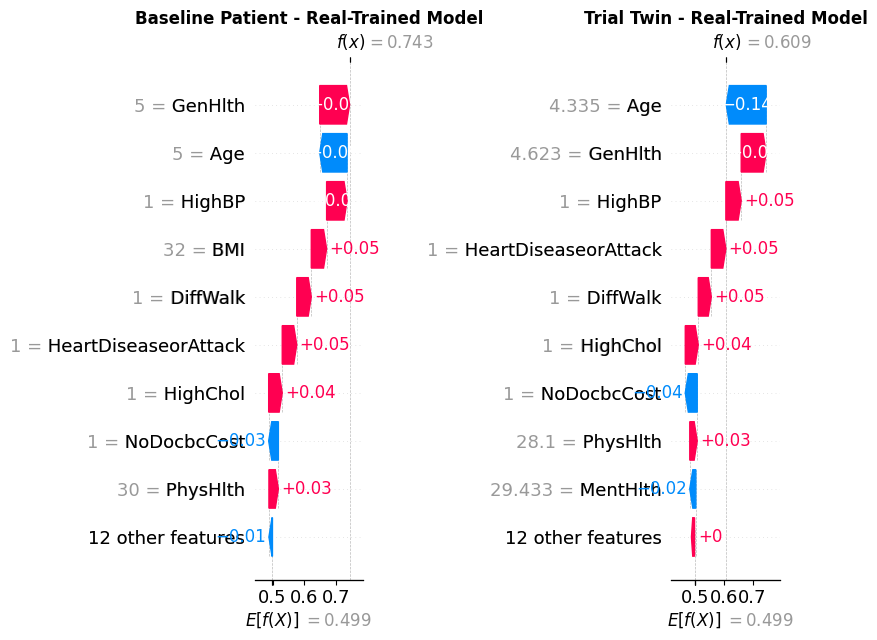

,baseline_shap,trial_twin_shap,shap_delta,abs_shift
BMI,0.048421,-0.006560,-0.054982,0.054982
Age,-0.086497,-0.137856,-0.051359,0.051359
HighBP,0.064699,0.053024,-0.011675,0.011675
NoDocbcCost,-0.030635,-0.041345,-0.010710,0.010710
GenHlth,0.094330,0.086249,-0.008080,0.008080
MentHlth,-0.026538,-0.020978,0.005560,0.005560
HeartDiseaseorAttack,0.045850,0.050292,0.004442,0.004442
PhysHlth,0.029824,0.025795,-0.004030,0.004030


In [19]:
baseline_trial_df = pd.DataFrame([trial_result["baseline_features"]])
trial_twin_df = pd.DataFrame([trial_result["trial_twin_features"]])

baseline_trial_shap = explainer_real.shap_values(baseline_trial_df)
trial_twin_shap = explainer_real.shap_values(trial_twin_df)

if isinstance(baseline_trial_shap, list):
    baseline_trial_sv = baseline_trial_shap[1][0]
    trial_twin_sv = trial_twin_shap[1][0]
elif len(np.array(baseline_trial_shap).shape) == 3:
    baseline_trial_sv = baseline_trial_shap[:, :, 1][0]
    trial_twin_sv = trial_twin_shap[:, :, 1][0]
else:
    baseline_trial_sv = baseline_trial_shap[0]
    trial_twin_sv = trial_twin_shap[0]

base_real = explainer_real.expected_value[1] if isinstance(explainer_real.expected_value, (list, np.ndarray)) else explainer_real.expected_value

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.plots.waterfall(
    shap.Explanation(
        values=baseline_trial_sv,
        base_values=base_real,
        data=baseline_trial_df.iloc[0],
        feature_names=list(baseline_trial_df.columns),
    ),
    show=False,
)
axes[0].set_title("Baseline Patient - Real-Trained Model", fontweight="bold")

plt.sca(axes[1])
shap.plots.waterfall(
    shap.Explanation(
        values=trial_twin_sv,
        base_values=base_real,
        data=trial_twin_df.iloc[0],
        feature_names=list(trial_twin_df.columns),
    ),
    show=False,
)
axes[1].set_title("Trial Twin - Real-Trained Model", fontweight="bold")
plt.tight_layout()
plt.show()

shap_shift = pd.DataFrame(
    {
        "baseline_shap": baseline_trial_sv,
        "trial_twin_shap": trial_twin_sv,
        "shap_delta": trial_twin_sv - baseline_trial_sv,
    },
    index=baseline_trial_df.columns,
).assign(abs_shift=lambda frame: frame["shap_delta"].abs()).sort_values("abs_shift", ascending=False)

shap_shift.head(8)


In [20]:
artifacts_dir = Path("backend/model_artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

simulation_bundle = export_simulation_bundle(
    context=simulation_context,
    feature_importances=feature_importances_real.to_dict(),
    demo_patient=trial_result["baseline_features"],
)

with open(artifacts_dir / "simulation_bundle.pkl", "wb") as handle:
    pickle.dump(simulation_bundle, handle)

joblib.dump(rf_real, artifacts_dir / "risk_model.joblib")

future_pipeline_contract = {
    "pdf_parser_output": ["trial title", "cohort summary", "endpoint text"],
    "retrieval_output": ["mechanism evidence", "supporting citations"],
    "reasoning_output": ["gamma", "reasoning_brief", "expected_biomarker_effect"],
}

print("Artifacts exported for backend reuse:")
print(f"- {artifacts_dir / 'simulation_bundle.pkl'}")
print(f"- {artifacts_dir / 'risk_model.joblib'}")
print()
print("Future pipeline contract:")
future_pipeline_contract


Artifacts exported for backend reuse:
- backend/model_artifacts/simulation_bundle.pkl
- backend/model_artifacts/risk_model.joblib

Future pipeline contract:


{'pdf_parser_output': ['trial title', 'cohort summary', 'endpoint text'],
 'retrieval_output': ['mechanism evidence', 'supporting citations'],
 'reasoning_output': ['gamma', 'reasoning_brief', 'expected_biomarker_effect']}